<a href="https://colab.research.google.com/github/vicha1234/TelcoChurnPrediction/blob/main/2425610.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load the data set**

In [3]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Perform EDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
telco=df['Churn']
telco

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [9]:
print(telco.isnull().sum())

0


In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [12]:
df.shape

(7043, 21)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [14]:
print(df['TotalCharges'].isnull().sum())

11


In [15]:
df = df.dropna(subset=['TotalCharges'])

In [16]:
df = df.drop('customerID', axis=1)

In [17]:
cols_to_clean = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in cols_to_clean:
    df[col] = df[col].replace({'No internet service': 'No'})


In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [19]:
df.shape

(7032, 20)

In [20]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


**EDA Visualization**

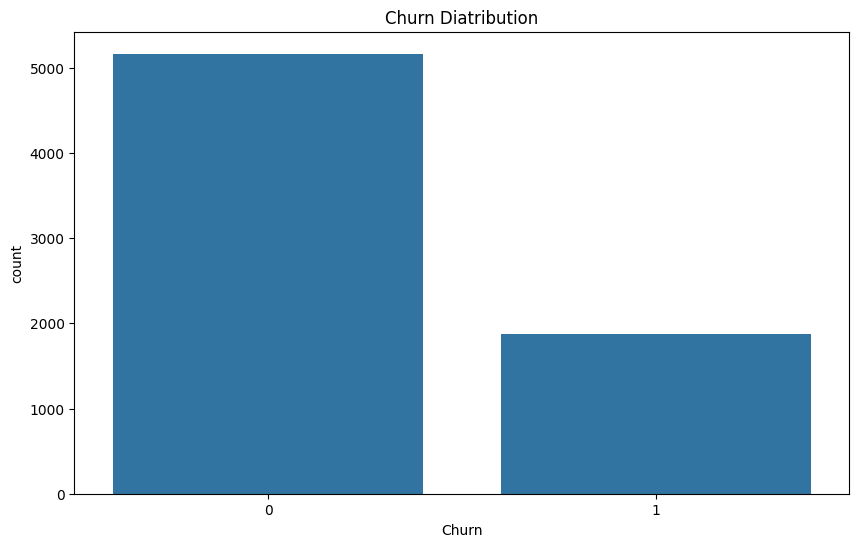

,proportion
Churn,
0,0.734215
1,0.265785


In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='Churn',data=df)
plt.title('Churn Diatribution')
plt.show()

df['Churn'].value_counts(normalize=True)

The dataset is imbalanced.Arount 26% customer churn and around 74% customer stay.(The dataset is imbalanced with 26% churn and 74% non-churn.)

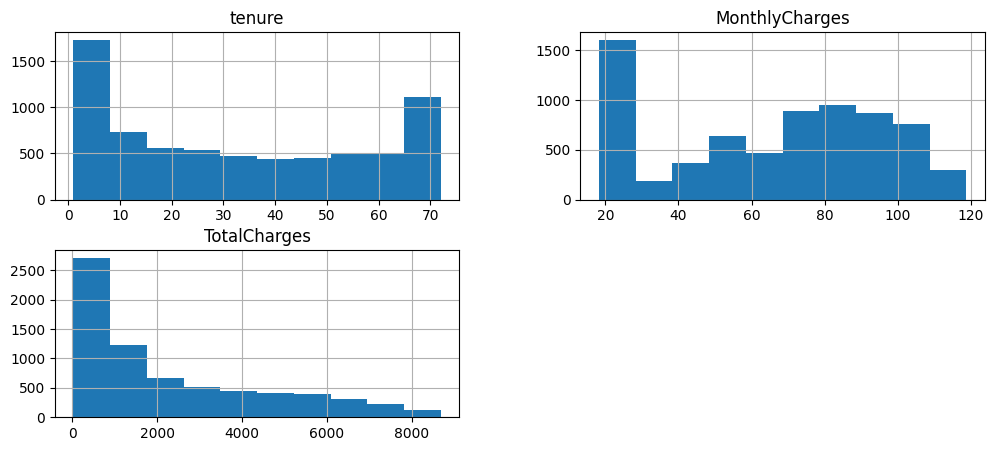

In [22]:
df[['tenure','MonthlyCharges','TotalCharges']].hist(figsize=(12,5))
plt.show()

Tenure distribution shows many customers are relatively new,which may relate to high churn risk.MonthlyCharges has higher values concentrated for churned customers.

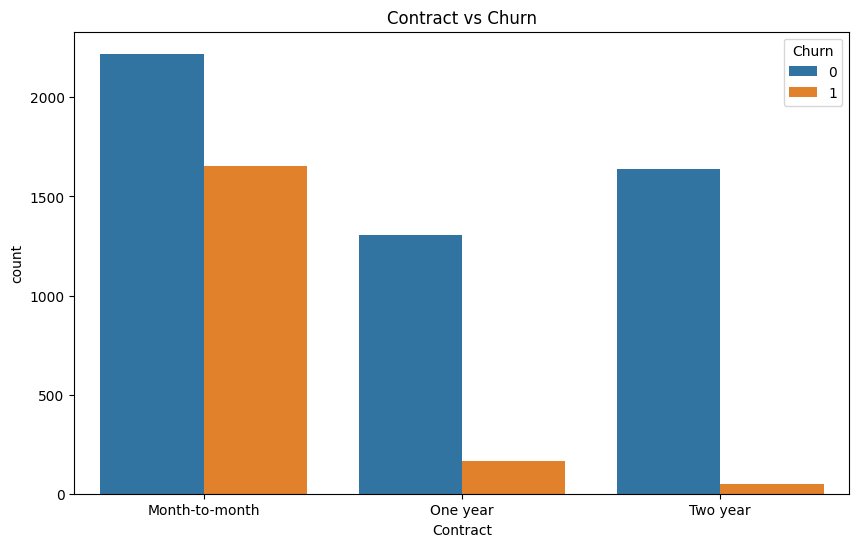

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title('Contract vs Churn')
plt.xticks(rotation=0)
plt.show()

Month to month customers churn the most.One year and two year contract customers rarely churn.Contract length is a strong predictor of churn

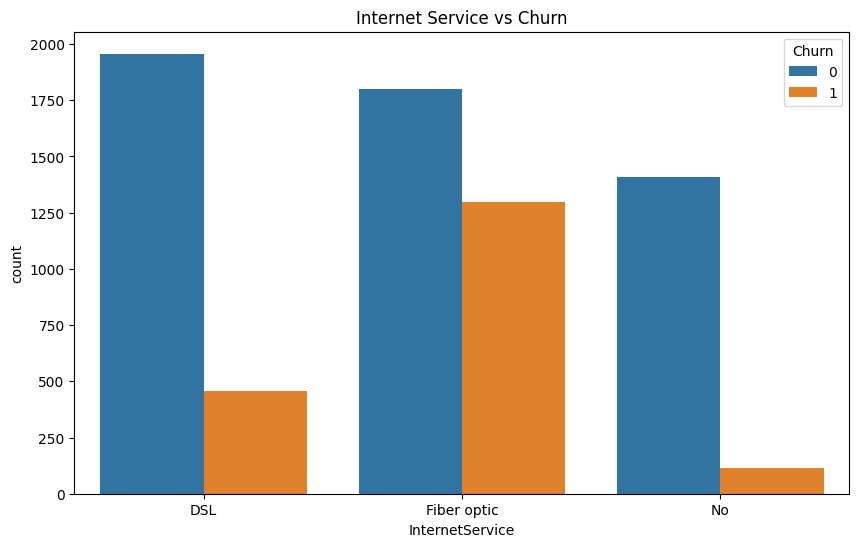

In [24]:
plt.figure(figsize=(10,6))
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.title('Internet Service vs Churn')
plt.show()

Fiber optic customers show high churn.DSL and no internet customers churn less.

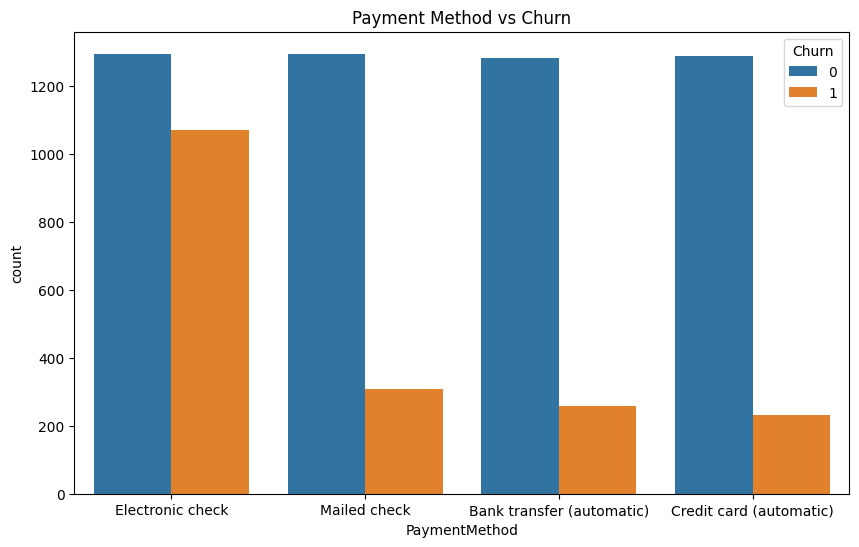

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=0)
plt.show()

Electronic check users churn the most.
Credit card users churn the least.

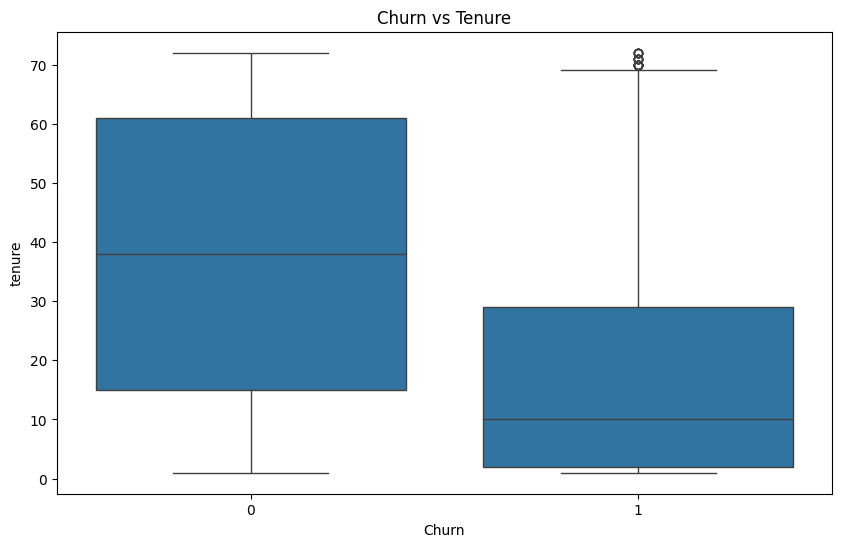

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title('Churn vs Tenure')
plt.show()

Churned customers generally have very low tenure.
Long term customers rarely churn.

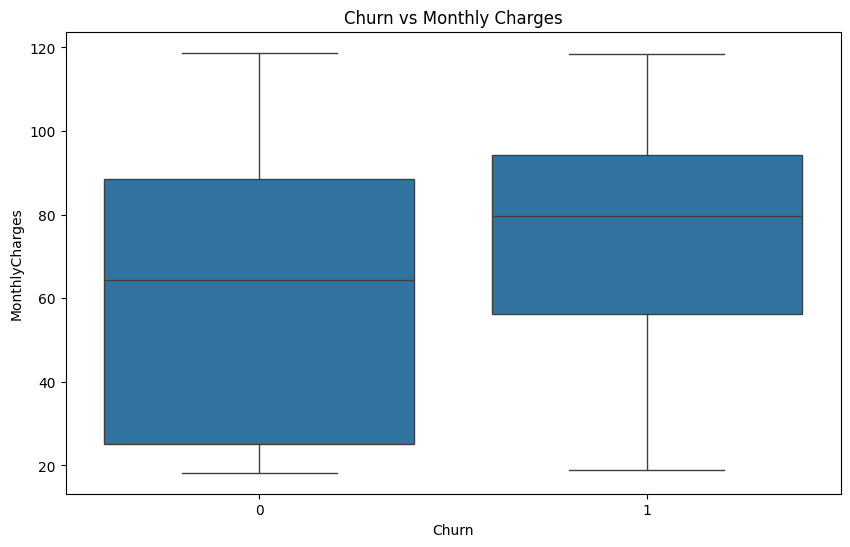

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('Churn vs Monthly Charges')
plt.show()

Cuatomers with higher monthly charges churn more.Low paying cutomers churn less.

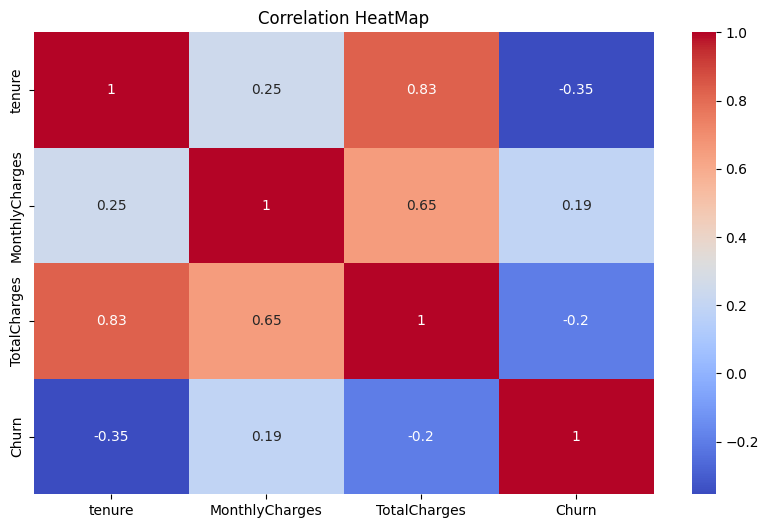

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation HeatMap')
plt.show()

Tenure is stongly negatively correlated with churn.Higher MonthlyCharges correlates with higher churn.TotalCharges correlates with tenure.

# **Task 2 - Preprocessing Part**

In [29]:
#Split X and y
X=df.drop('Churn',axis=1)
y=df['Churn']

#Train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
#Encode categorical variables

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols=X.select_dtypes(include=['object']).columns
numerical_cols=X.select_dtypes(include=['int64','float64']).columns

encoder=ColumnTransformer(transformers=[('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols)],remainder='passthrough')

X_train_encoded=encoder.fit_transform(X_train)
X_test_encoded=encoder.transform(X_test)

#categorical_cols,numerical_cols

In [35]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_resampled,y_train_resampled=smote.fit_resample(X_train_encoded,y_train)

y_train_resampled.value_counts()

,count
Churn,
0,4130
1,4130


In [37]:
#Scale data(for NN)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_resampled)
x_test_scaled=scaler.transform(X_test_encoded)

# **Decision Tree**

In [40]:
#Train decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(class_weight="balanced",random_state=42)
dt_model.fit(X_train_resampled,y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [42]:
#predict on test set
dt_predict=dt_model.predict(X_test_encoded)

array([0, 0, 0, ..., 1, 0, 0])

In [44]:
#Evaluate the model
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score

print("Accuracy:",accuracy_score(y_test,dt_predict))
print("Precision :",precision_score(y_test,dt_predict))
print("Recall :",recall_score(y_test,dt_predict))
print("F1 Score :",f1_score(y_test,dt_predict))

print("\nClassification Report:\n",classification_report(y_test,dt_predict))

Accuracy: 0.7270788912579957
Precision : 0.4875
Recall : 0.5213903743315508
F1 Score : 0.5038759689922481

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.52      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407

